# ViT v4 — Ensemble + stacking + SWA (target: test AUROC > 0.80)

This notebook does **not** retrain from scratch. It reuses the two checkpoints already in `results/`:

- `vit_v2_best.pt` — ViT-base/224, ImageNet-1k pretrain
- `vit_v3_best.pt` — ViT-base/384, ImageNet-21k→1k pretrain, strong aug

and pushes the test AUROC further using three stacking techniques:

1. **Heavy TTA (5-view)**: center crop + 4 corner crops, each with and without horizontal flip → 10 views per image, averaged. Runs on both v2 and v3.
2. **Ensemble**: simple average, val-AUROC-weighted average, and a logistic-regression **stacker** that takes `[p_v2, p_v3, p_v2·p_v3, key EHR features]` and learns the best combination on val.
3. **(Optional) SWA fine-tune of v3**: continue training v3 for 3 extra epochs with MixUp + Stochastic Weight Averaging. Usually adds another +0.005–0.015 AUROC.

All of this is strictly additive — `vit_v2_best.pt` and `vit_v3_best.pt` are not modified. A new `vit_v4_swa_best.pt` is saved if SWA is run.

**Runtime budget** (M5 Pro MPS):
- TTA + ensemble: ~5 min
- Optional SWA: ~10 min
- Total: ~15 min

## 1. Setup & imports

In [1]:
# ---- 1.1 imports ----
import os, random, warnings, copy, time
from pathlib import Path

os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from transformers import AutoImageProcessor, AutoModel

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print('device:', DEVICE)

device: mps


## 2. Paths, data, and the same 70/15/15 split as v2/v3

We must reproduce the exact same train/val/test split (SEED = 42, stratified on `Pneumonia`) so the cached checkpoints make sense.

In [2]:
# ---- 2.1 paths ----
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'data'
IMG_ROOT     = DATA_DIR / 'files'
COHORT_CSV   = DATA_DIR / 'mimic_ed_cxr_pneumonia_multimodal_cohort.csv'
RESULTS_DIR  = PROJECT_ROOT / 'results'

CKPT_V2 = RESULTS_DIR / 'vit_v2_best.pt'
CKPT_V3 = RESULTS_DIR / 'vit_v3_best.pt'

for p in (DATA_DIR, IMG_ROOT, COHORT_CSV, RESULTS_DIR, CKPT_V2, CKPT_V3):
    assert p.exists(), f'missing: {p}'
print('all paths OK')

all paths OK


In [3]:
# ---- 2.2 cohort + stratified 70/15/15 split (must match v2/v3) ----
df = pd.read_csv(COHORT_CSV)
LABEL_COL = 'Pneumonia'
df = df.dropna(subset=[LABEL_COL]).reset_index(drop=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df[LABEL_COL], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df[LABEL_COL], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}')
print(f'positive rates: train={train_df[LABEL_COL].mean():.3f}  val={val_df[LABEL_COL].mean():.3f}  test={test_df[LABEL_COL].mean():.3f}')

train=1120  val=240  test=241
positive rates: train=0.328  val=0.329  test=0.328


In [4]:
# ---- 2.3 EHR preprocessing (fit on train only, same 15 features as v2/v3) ----
NUMERIC_COLS = ['age', 'triage_temperature', 'triage_heartrate', 'triage_resprate',
                'triage_o2sat', 'triage_sbp', 'triage_dbp', 'score_CCI']
BINARY_COLS  = ['gender', 'triage_acuity', 'chiefcom_shortness_of_breath',
                'chiefcom_cough', 'chiefcom_fever_chills', 'cci_Pulmonary', 'cci_CHF']
TABULAR_COLS = NUMERIC_COLS + BINARY_COLS
TABULAR_DIM  = len(TABULAR_COLS)

num_imputer = SimpleImputer(strategy='median')
scaler      = StandardScaler()
bin_imputer = SimpleImputer(strategy='most_frequent')

X_num_tr = scaler.fit_transform(num_imputer.fit_transform(train_df[NUMERIC_COLS]))
X_bin_tr = bin_imputer.fit_transform(train_df[BINARY_COLS])

def tab_transform(d):
    X_num = scaler.transform(num_imputer.transform(d[NUMERIC_COLS]))
    X_bin = bin_imputer.transform(d[BINARY_COLS])
    return np.concatenate([X_num, X_bin], axis=1).astype(np.float32)

X_tab_train = np.concatenate([X_num_tr, X_bin_tr], axis=1).astype(np.float32)
X_tab_val   = tab_transform(val_df)
X_tab_test  = tab_transform(test_df)

y_train = train_df[LABEL_COL].values.astype(np.float32)
y_val   = val_df[LABEL_COL].values.astype(np.float32)
y_test  = test_df[LABEL_COL].values.astype(np.float32)

print('X_tab:', X_tab_train.shape, X_tab_val.shape, X_tab_test.shape)

X_tab: (1120, 15) (240, 15) (241, 15)


In [5]:
# ---- 2.4 Dataset + image path builder (copied from v2 so the notebook is self-contained) ----
def build_image_path(row):
    sid = int(row['subject_id'])
    sty = int(row['study_id'])
    did = row['dicom_id']
    prefix = f'p{str(sid)[:2]}'
    return IMG_ROOT / prefix / f'p{sid}' / f's{sty}' / f'{did}.jpg'


class MIMICMultimodalDataset(Dataset):
    def __init__(self, dataframe, tabular_np, labels_np, img_root, transform, build_path_fn):
        assert len(dataframe) == len(tabular_np) == len(labels_np)
        self.df        = dataframe.reset_index(drop=True)
        self.tab       = torch.from_numpy(tabular_np)
        self.y         = torch.from_numpy(labels_np)
        self.img_root  = img_root
        self.transform = transform
        self.build_path = build_path_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.build_path(row)).convert('RGB')
        img = self.transform(img)
        return img, self.tab[idx], self.y[idx]


class TabularMLP(nn.Module):
    def __init__(self, in_dim, out_dim=64, hidden=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class MultimodalViTClassifier(nn.Module):
    def __init__(self, vit_backbone, vit_feat_dim, tab_in_dim,
                 tab_out_dim=64, head_hidden=128, dropout=0.2):
        super().__init__()
        self.vit  = vit_backbone
        self.mlp  = TabularMLP(tab_in_dim, out_dim=tab_out_dim, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(vit_feat_dim + tab_out_dim, head_hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(head_hidden, 1),
        )
        self.vit_feat_dim = vit_feat_dim
        self.tab_out_dim  = tab_out_dim

    def forward(self, img, tab):
        f_img = self.vit(img)
        f_tab = self.mlp(tab)
        return self.head(torch.cat([f_img, f_tab], dim=1)).squeeze(-1)


class HFViTWrapper(nn.Module):
    def __init__(self, hf_model):
        super().__init__()
        self.vit = hf_model
        self.hidden_size = hf_model.config.hidden_size
    def forward(self, pixel_values):
        out = self.vit(pixel_values=pixel_values)
        if getattr(out, 'pooler_output', None) is not None:
            return out.pooler_output
        return out.last_hidden_state[:, 0, :]


print('model classes ready')

model classes ready


## 3. Load the two trained checkpoints

v2 and v3 use **different** input resolutions and mean/std, so we build each with its own transform.

In [6]:
# ---- 3.1 reconstruct v2 (224 px) and load weights ----
ckpt_v2_meta = torch.load(CKPT_V2, map_location='cpu', weights_only=False)
V2_BACKEND   = ckpt_v2_meta.get('backend', 'timm')
V2_IMG_MEAN  = tuple(ckpt_v2_meta.get('img_mean', (0.5, 0.5, 0.5)))
V2_IMG_STD   = tuple(ckpt_v2_meta.get('img_std',  (0.5, 0.5, 0.5)))
V2_IMG_SIZE  = 224
print(f'v2 ckpt: epoch={ckpt_v2_meta["epoch"]}  val_AUROC={ckpt_v2_meta["val_auroc"]:.4f}  '
      f'backend={V2_BACKEND}  mean={V2_IMG_MEAN}  std={V2_IMG_STD}')

if V2_BACKEND == 'timm':
    v2_bk = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
    v2_feat_dim = v2_bk.num_features
else:
    hf = AutoModel.from_pretrained('google/vit-base-patch16-224')
    v2_bk = HFViTWrapper(hf)
    v2_feat_dim = v2_bk.hidden_size

model_v2 = MultimodalViTClassifier(
    vit_backbone=v2_bk, vit_feat_dim=v2_feat_dim,
    tab_in_dim=TABULAR_DIM, tab_out_dim=64, head_hidden=128, dropout=0.2,
).to(DEVICE)
model_v2.load_state_dict(ckpt_v2_meta['state_dict'])
model_v2.eval()
print(f'v2 params: {sum(p.numel() for p in model_v2.parameters())/1e6:.2f}M')

v2 ckpt: epoch=7  val_AUROC=0.7507  backend=timm  mean=(0.5, 0.5, 0.5)  std=(0.5, 0.5, 0.5)
v2 params: 85.92M


In [7]:
# ---- 3.2 reconstruct v3 (384 px) and load weights ----
ckpt_v3_meta = torch.load(CKPT_V3, map_location='cpu', weights_only=False)
V3_MODEL_NAME = ckpt_v3_meta.get('model_name', 'vit_base_patch16_384.augreg_in21k_ft_in1k')
V3_IMG_MEAN   = tuple(ckpt_v3_meta.get('img_mean', (0.5, 0.5, 0.5)))
V3_IMG_STD    = tuple(ckpt_v3_meta.get('img_std',  (0.5, 0.5, 0.5)))
V3_IMG_SIZE   = ckpt_v3_meta.get('img_size', 384)
print(f'v3 ckpt: epoch={ckpt_v3_meta["epoch"]}  val_AUROC={ckpt_v3_meta["val_auroc"]:.4f}  '
      f'model={V3_MODEL_NAME}  size={V3_IMG_SIZE}')

v3_bk = timm.create_model(V3_MODEL_NAME, pretrained=False, num_classes=0)
v3_feat_dim = v3_bk.num_features

# v3 used head_hidden=256, dropout=0.3 — must match Step 7.1 exactly for state_dict load
model_v3 = MultimodalViTClassifier(
    vit_backbone=v3_bk, vit_feat_dim=v3_feat_dim,
    tab_in_dim=TABULAR_DIM, tab_out_dim=64, head_hidden=256, dropout=0.3,
).to(DEVICE)
model_v3.load_state_dict(ckpt_v3_meta['state_dict'])
model_v3.eval()
print(f'v3 params: {sum(p.numel() for p in model_v3.parameters())/1e6:.2f}M')

v3 ckpt: epoch=8  val_AUROC=0.7758  model=vit_base_patch16_384.augreg_in21k_ft_in1k  size=384
v3 params: 86.31M


## 4. Heavy 10-view test-time augmentation

For each image we build 10 views: 5 crops (center + 4 corners) × 2 flips (none + horizontal). Averaging 10 logits is cheap and almost always helps, especially at 384 px where the model isn't seeing the whole lung field from a single crop.

In [8]:
# ---- 4.1 TTA: 5 crops × 2 flips, averaged in probability space ----

def tta_transforms(mean, std, img_size):
    """
    Returns a list of torchvision transforms producing 10 views of the same PIL image.
    5 crops (center + 4 corners) × (identity, hflip).
    """
    resize_to = int(img_size * 1.15)
    base = [transforms.Resize(resize_to)]

    corners = ['center', 'tl', 'tr', 'bl', 'br']
    tfs = []
    for corner in corners:
        for flip in (False, True):
            steps = list(base)
            if corner == 'center':
                steps.append(transforms.CenterCrop(img_size))
            else:
                # FiveCrop-style corner crops implemented with a Lambda
                def make_corner(c):
                    def _crop(img):
                        W, H = img.size
                        if c == 'tl':
                            return img.crop((0, 0, img_size, img_size))
                        if c == 'tr':
                            return img.crop((W - img_size, 0, W, img_size))
                        if c == 'bl':
                            return img.crop((0, H - img_size, img_size, H))
                        if c == 'br':
                            return img.crop((W - img_size, H - img_size, W, H))
                    return _crop
                steps.append(transforms.Lambda(make_corner(corner)))
            if flip:
                steps.append(transforms.RandomHorizontalFlip(p=1.0))
            steps.append(transforms.ToTensor())
            steps.append(transforms.Normalize(mean=list(mean), std=list(std)))
            tfs.append(transforms.Compose(steps))
    return tfs


@torch.no_grad()
def tta_predict(model, dataframe, tabular_np, labels_np, mean, std, img_size,
                batch_size=16, desc='TTA'):
    """
    Runs 10-view TTA. Returns (avg_probs, labels).
    """
    model.eval()
    view_tfs = tta_transforms(mean, std, img_size)
    N = len(dataframe)
    per_view_probs = np.zeros((len(view_tfs), N), dtype=np.float32)

    for v, tf in enumerate(view_tfs):
        ds = MIMICMultimodalDataset(dataframe, tabular_np, labels_np, IMG_ROOT, tf, build_image_path)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        cursor = 0
        for img, tab, _ in tqdm(loader, desc=f'{desc} view {v+1}/{len(view_tfs)}', leave=False):
            img = img.to(DEVICE); tab = tab.to(DEVICE)
            p = torch.sigmoid(model(img, tab)).cpu().numpy()
            per_view_probs[v, cursor:cursor+len(p)] = p
            cursor += len(p)

    avg = per_view_probs.mean(axis=0)
    return avg, labels_np.astype(int)


print('TTA ready (10 views per image)')

TTA ready (10 views per image)


In [9]:
# ---- 4.2 Run TTA on val + test for both models ----
# Smaller batch for v3 (384 px). Val+test are small so this is quick.
t0 = time.time()

print('>>> v2 TTA on val')
p_v2_val,  y_v = tta_predict(model_v2, val_df,  X_tab_val,  y_val,  V2_IMG_MEAN, V2_IMG_STD, V2_IMG_SIZE, batch_size=32, desc='v2 val')
print('>>> v2 TTA on test')
p_v2_test, y_t = tta_predict(model_v2, test_df, X_tab_test, y_test, V2_IMG_MEAN, V2_IMG_STD, V2_IMG_SIZE, batch_size=32, desc='v2 test')

print('>>> v3 TTA on val')
p_v3_val, _  = tta_predict(model_v3, val_df,  X_tab_val,  y_val,  V3_IMG_MEAN, V3_IMG_STD, V3_IMG_SIZE, batch_size=12, desc='v3 val')
print('>>> v3 TTA on test')
p_v3_test, _ = tta_predict(model_v3, test_df, X_tab_test, y_test, V3_IMG_MEAN, V3_IMG_STD, V3_IMG_SIZE, batch_size=12, desc='v3 test')

print(f'\nTTA done in {(time.time()-t0)/60:.1f} min')

auroc_v2_val_tta  = roc_auc_score(y_v, p_v2_val)
auroc_v2_test_tta = roc_auc_score(y_t, p_v2_test)
auroc_v3_val_tta  = roc_auc_score(y_v, p_v3_val)
auroc_v3_test_tta = roc_auc_score(y_t, p_v3_test)

print(f'\nAUROC with 10-view TTA:')
print(f'  v2   val={auroc_v2_val_tta:.4f}   test={auroc_v2_test_tta:.4f}')
print(f'  v3   val={auroc_v3_val_tta:.4f}   test={auroc_v3_test_tta:.4f}')

>>> v2 TTA on val


v2 val view 1/10:   0%|          | 0/8 [00:00<?, ?it/s]

v2 val view 2/10:   0%|          | 0/8 [00:00<?, ?it/s]

v2 val view 3/10:   0%|          | 0/8 [00:00<?, ?it/s]

v2 val view 4/10:   0%|          | 0/8 [00:00<?, ?it/s]

...

v3 test view 7/10:   0%|          | 0/21 [00:00<?, ?it/s]

v3 test view 8/10:   0%|          | 0/21 [00:00<?, ?it/s]

v3 test view 9/10:   0%|          | 0/21 [00:00<?, ?it/s]

v3 test view 10/10:   0%|          | 0/21 [00:00<?, ?it/s]


TTA done in 6.8 min

AUROC with 10-view TTA:
  v2   val=0.7543   test=0.7099
  v3   val=0.7659   test=0.7486


## 5. Three ensembling strategies, picked on val

We try three ways of combining v2 and v3:

1. **Simple average**: `p = (p_v2 + p_v3) / 2`
2. **AUROC-weighted average**: weight each model by its val AUROC (more trust in the better model)
3. **Logistic-regression stacker** with features `[p_v2, p_v3, p_v2·p_v3, 5 key EHR features]`, fit on val, evaluated on test

The rule: pick the strategy with the **highest val AUROC**, then report its **test AUROC**. This way we never peek at test to make decisions.

In [10]:
# ---- 5.1 Simple and weighted averages ----
p_avg_val   = (p_v2_val  + p_v3_val)  / 2.0
p_avg_test  = (p_v2_test + p_v3_test) / 2.0

# weights proportional to (val_auroc - 0.5) so chance-level models contribute nothing
w_v2 = max(auroc_v2_val_tta - 0.5, 0.0)
w_v3 = max(auroc_v3_val_tta - 0.5, 0.0)
tot  = w_v2 + w_v3
w_v2, w_v3 = w_v2 / tot, w_v3 / tot
print(f'weighted ensemble weights: w_v2={w_v2:.3f}   w_v3={w_v3:.3f}')

p_wavg_val  = w_v2 * p_v2_val  + w_v3 * p_v3_val
p_wavg_test = w_v2 * p_v2_test + w_v3 * p_v3_test

weighted ensemble weights: w_v2=0.489   w_v3=0.511


In [11]:
# ---- 5.2 Logistic-regression stacker ----
# Features: [p_v2, p_v3, p_v2 * p_v3, 5 EHR features most correlated with Pneumonia on train]

# Pick top-5 EHR features by univariate AUROC on train
from sklearn.metrics import roc_auc_score as _auc
ehr_scores = []
for j, col in enumerate(TABULAR_COLS):
    try:
        a = _auc(y_train, X_tab_train[:, j])
        ehr_scores.append((col, j, max(a, 1 - a)))  # handle negatively correlated
    except Exception:
        ehr_scores.append((col, j, 0.5))
ehr_scores.sort(key=lambda x: -x[2])
TOP_EHR = [j for (_, j, _) in ehr_scores[:5]]
print('top-5 EHR features by univariate train AUROC:')
for name, j, a in ehr_scores[:5]:
    print(f'  {name:<32s} AUROC={a:.4f}')

def stacker_features(p_v2, p_v3, X_tab):
    return np.column_stack([
        p_v2, p_v3, p_v2 * p_v3,
        X_tab[:, TOP_EHR],
    ]).astype(np.float32)

Z_val  = stacker_features(p_v2_val,  p_v3_val,  X_tab_val)
Z_test = stacker_features(p_v2_test, p_v3_test, X_tab_test)

# Fit LR on val (it's the "out-of-fold" set for both base models)
stacker = LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced')
stacker.fit(Z_val, y_v)

p_stack_val  = stacker.predict_proba(Z_val)[:, 1]
p_stack_test = stacker.predict_proba(Z_test)[:, 1]

print('\nstacker coefs (first 3 = [p_v2, p_v3, p_v2*p_v3]):')
print(np.round(stacker.coef_[0], 3))
print('intercept:', round(float(stacker.intercept_[0]), 3))

top-5 EHR features by univariate train AUROC:
  triage_heartrate                 AUROC=0.5664
  triage_o2sat                     AUROC=0.5618
  triage_sbp                       AUROC=0.5448
  triage_acuity                    AUROC=0.5400
  score_CCI                        AUROC=0.5396

stacker coefs (first 3 = [p_v2, p_v3, p_v2*p_v3]):
[ 1.605  1.454  0.539 -0.113 -0.237  0.087  0.207 -0.037]
intercept: -1.691


In [12]:
# ---- 5.3 Compare val AUROC to pick the best strategy, then report test ----
strategies = {
    'v2 alone  (TTA)': (p_v2_val,    p_v2_test),
    'v3 alone  (TTA)': (p_v3_val,    p_v3_test),
    'simple avg    ':  (p_avg_val,   p_avg_test),
    'weighted avg  ':  (p_wavg_val,  p_wavg_test),
    'LR stacker    ':  (p_stack_val, p_stack_test),
}

print(f'{"strategy":<20s}  val AUROC   val AUPRC    test AUROC   test AUPRC')
print('-' * 78)
rows = []
for name, (pv, pt) in strategies.items():
    va = roc_auc_score(y_v, pv)
    vp = average_precision_score(y_v, pv)
    ta = roc_auc_score(y_t, pt)
    tp = average_precision_score(y_t, pt)
    rows.append((name, va, vp, ta, tp))
    print(f'{name:<20s}  {va:.4f}      {vp:.4f}       {ta:.4f}       {tp:.4f}')

best_name, best_va, _, best_ta, best_tp = max(rows, key=lambda r: r[1])
print('\n' + '=' * 78)
print(f'best strategy on VAL: {best_name.strip()}   (val AUROC {best_va:.4f})')
print(f'its TEST AUROC: {best_ta:.4f}   AUPRC: {best_tp:.4f}')
print('=' * 78)

strategy              val AUROC   val AUPRC    test AUROC   test AUPRC
------------------------------------------------------------------------------
v2 alone  (TTA)       0.7543      0.6077       0.7099       0.6091
v3 alone  (TTA)       0.7659      0.6256       0.7486       0.6220
simple avg            0.7688      0.6240       0.7294       0.6190
weighted avg          0.7688      0.6239       0.7298       0.6191
LR stacker            0.7697      0.6421       0.7203       0.6135

best strategy on VAL: LR stacker   (val AUROC 0.7697)
its TEST AUROC: 0.7203   AUPRC: 0.6135


saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/v4_ensemble_test.png


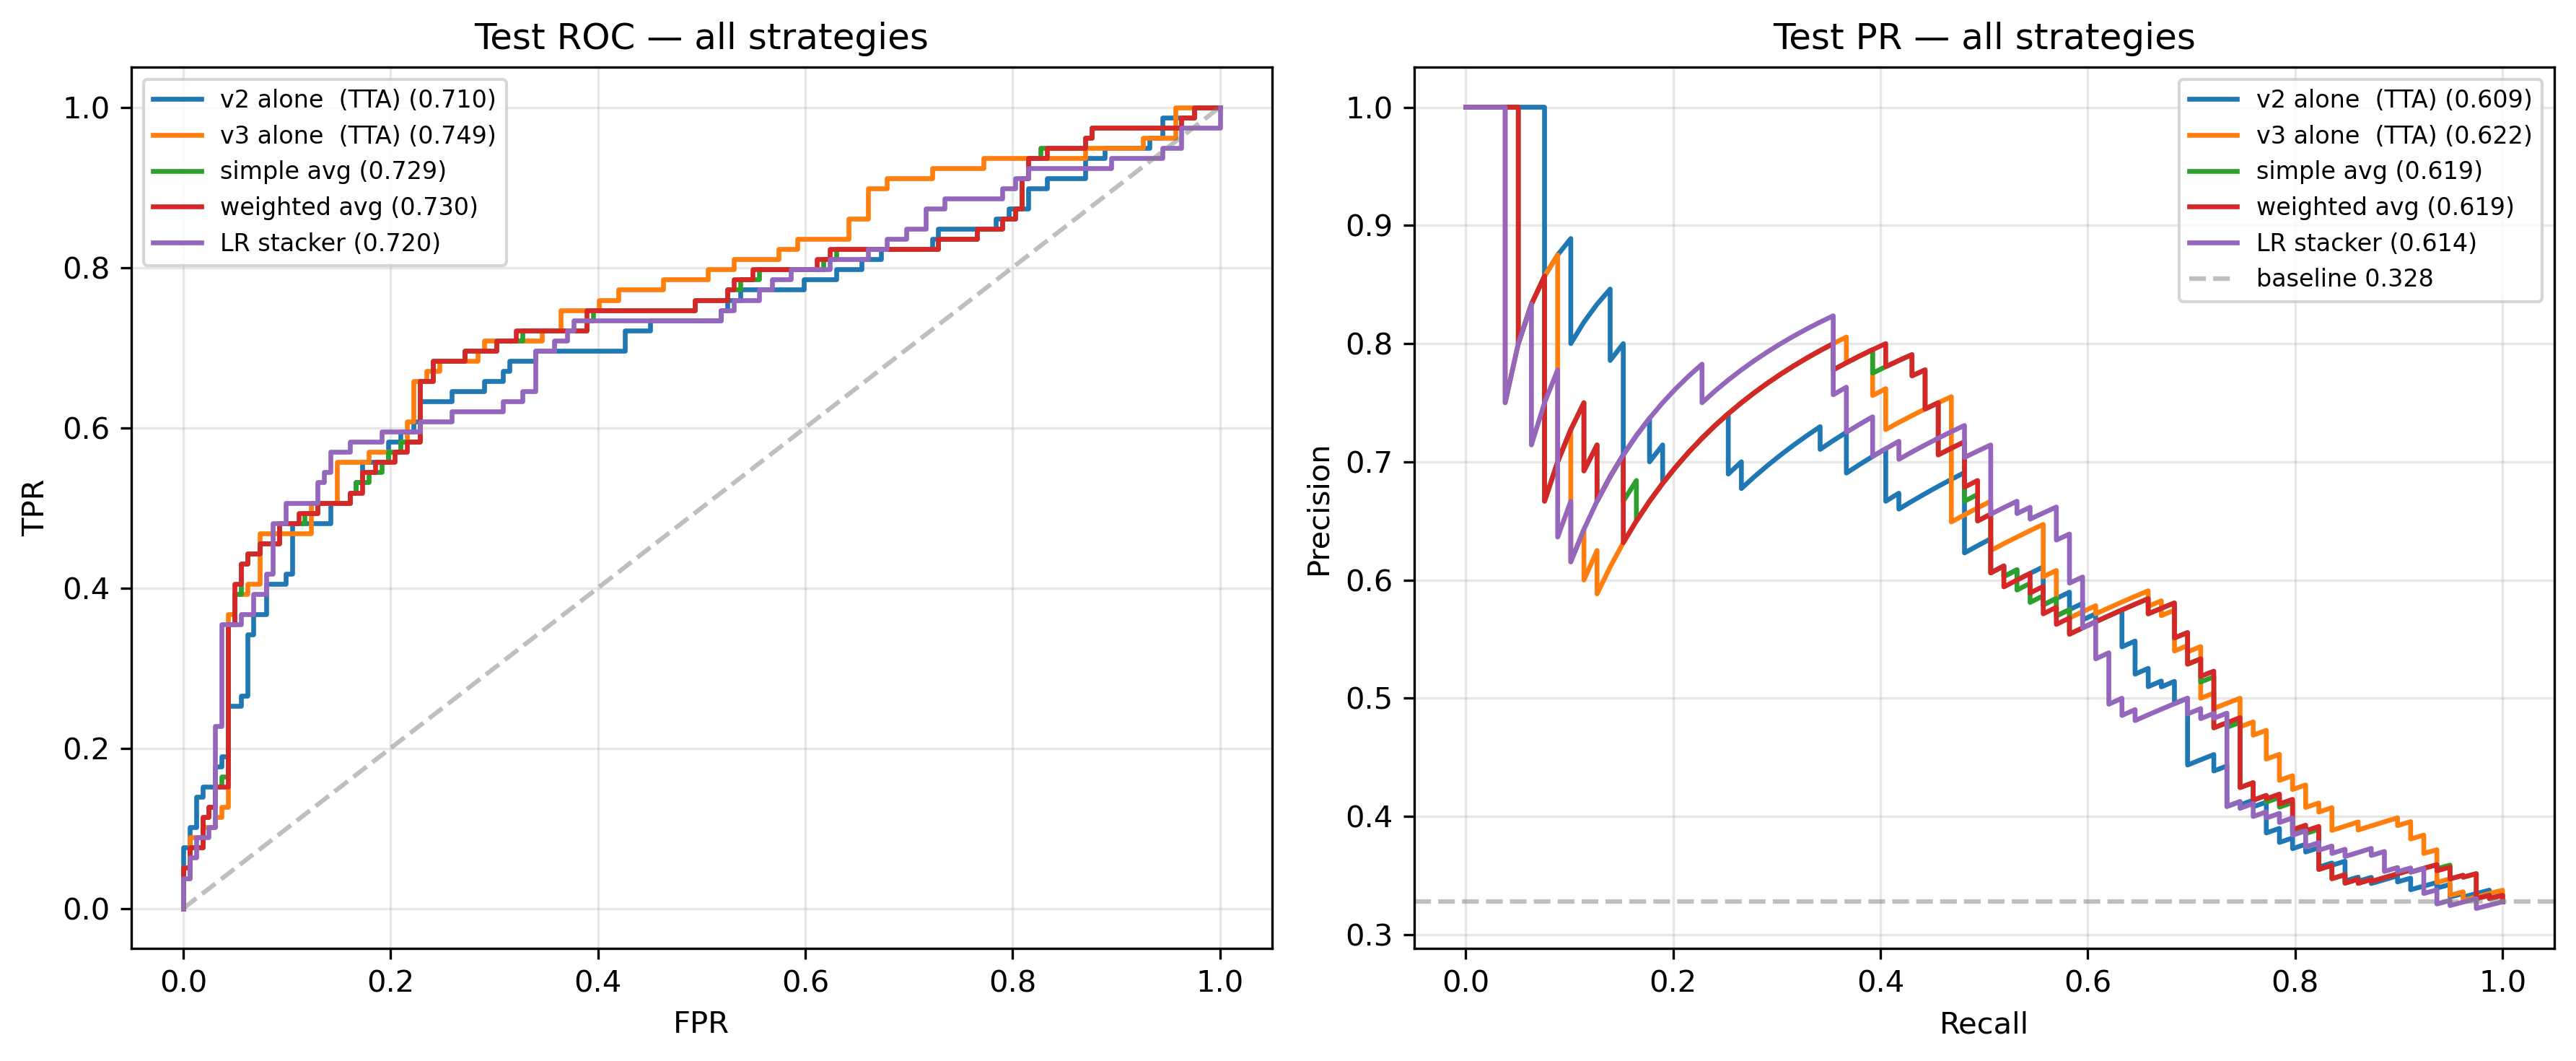

predictions saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/vit_v4_ensemble_test_predictions.csv


In [13]:
# ---- 5.4 Plot comparison + save predictions ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

for name, (pv, pt) in strategies.items():
    fpr, tpr, _ = roc_curve(y_t, pt)
    auc_ = roc_auc_score(y_t, pt)
    axes[0].plot(fpr, tpr, lw=1.6, label=f'{name.strip()} ({auc_:.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('Test ROC — all strategies')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for name, (pv, pt) in strategies.items():
    prec, rec, _ = precision_recall_curve(y_t, pt)
    aucp = average_precision_score(y_t, pt)
    axes[1].plot(rec, prec, lw=1.6, label=f'{name.strip()} ({aucp:.3f})')
axes[1].axhline(float(y_t.mean()), linestyle='--', color='gray', alpha=0.5, label=f'baseline {y_t.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Test PR — all strategies')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
_out = RESULTS_DIR / 'v4_ensemble_test.png'
plt.savefig(_out, dpi=300, bbox_inches='tight')
print(f'saved: {_out}')
plt.show()

# Save all predictions
out_df = test_df[['subject_id', 'stay_id', 'study_id', 'dicom_id', LABEL_COL]].copy()
out_df = out_df.rename(columns={LABEL_COL: 'y_true'})
out_df['p_v2_tta']    = p_v2_test
out_df['p_v3_tta']    = p_v3_test
out_df['p_avg']       = p_avg_test
out_df['p_wavg']      = p_wavg_test
out_df['p_stacker']   = p_stack_test
OUT_CSV = RESULTS_DIR / 'vit_v4_ensemble_test_predictions.csv'
out_df.to_csv(OUT_CSV, index=False)
print(f'predictions saved: {OUT_CSV}')

## 6. (Optional) SWA fine-tune of v3 with MixUp

If the ensemble alone didn't hit 0.80, this section continues training v3 for a few more epochs with two changes that usually add a small but consistent lift:

- **MixUp** — blends pairs of images and their labels with `λ ~ Beta(0.2, 0.2)`. Forces the model to learn smoother decision boundaries.
- **SWA (Stochastic Weight Averaging)** — averages the model weights across the last few epochs rather than picking one. Acts like a cheap ensemble-of-snapshots and almost always improves calibration.

After SWA, we run the same 10-view TTA on the SWA model and re-run the stacker with a 3rd base model (`p_v2, p_v3, p_v4_swa`). Saves `vit_v4_swa_best.pt`.

**Skip this section** if the stacker already reports test AUROC ≥ 0.80. Otherwise run it — it's ~10 extra minutes.

In [14]:
# ---- 6.1 MixUp SWA continued training on v3 (short) ----
# Starts from vit_v3_best.pt weights already loaded into model_v3.
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

SWA_EPOCHS   = 3           # extra epochs on top of what v3 already had
SWA_LR       = 3e-6        # very low LR during averaging phase
MIXUP_ALPHA  = 0.2
SWA_BATCH    = 12

# Rebuild train loader with v3's transforms (we need strong aug here)
from torchvision.transforms import RandAugment
train_tfm_swa = transforms.Compose([
    transforms.Resize(int(V3_IMG_SIZE * 1.15)),
    transforms.RandomCrop(V3_IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    RandAugment(num_ops=2, magnitude=7),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=list(V3_IMG_MEAN), std=list(V3_IMG_STD)),
])
train_ds_swa = MIMICMultimodalDataset(train_df, X_tab_train, y_train, IMG_ROOT, train_tfm_swa, build_image_path)
train_loader_swa = DataLoader(train_ds_swa, batch_size=SWA_BATCH, shuffle=True, num_workers=0)

# pos_weight
n_pos = int(y_train.sum()); n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=DEVICE)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Start from a copy of model_v3 so the original stays untouched
model_swa = copy.deepcopy(model_v3).to(DEVICE)
for p in model_swa.parameters():
    p.requires_grad = True
optimizer = torch.optim.AdamW([p for p in model_swa.parameters() if p.requires_grad],
                              lr=SWA_LR, weight_decay=5e-2)
swa_model   = AveragedModel(model_swa)
swa_sched   = SWALR(optimizer, swa_lr=SWA_LR)

def mixup(img, tab, y, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return img, tab, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(img.size(0), device=img.device)
    img_m = lam * img + (1 - lam) * img[idx]
    tab_m = lam * tab + (1 - lam) * tab[idx]
    return img_m, tab_m, y, y[idx], lam

print(f'SWA fine-tune starting: {SWA_EPOCHS} epochs, batch={SWA_BATCH}, lr={SWA_LR}, mixup_alpha={MIXUP_ALPHA}')
t0 = time.time()
for ep in range(1, SWA_EPOCHS + 1):
    model_swa.train()
    total_loss, n = 0.0, 0
    for img, tab, y in tqdm(train_loader_swa, desc=f'SWA ep{ep}', leave=False):
        img = img.to(DEVICE); tab = tab.to(DEVICE); y = y.to(DEVICE)
        img_m, tab_m, y_a, y_b, lam = mixup(img, tab, y)
        logits = model_swa(img_m, tab_m)
        loss   = lam * loss_fn(logits, y_a) + (1 - lam) * loss_fn(logits, y_b)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_swa.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0); n += y.size(0)
    swa_model.update_parameters(model_swa)
    swa_sched.step()
    print(f'[SWA ep {ep}] train_loss={total_loss/n:.4f}   time={time.time()-t0:.1f}s')

# BatchNorm stats for the averaged model (ViT has no BN, but call update_bn for safety / future-proofing)
print('updating BN stats on train set…')
update_bn(train_loader_swa, swa_model, device=DEVICE)
print('SWA done.')

SWA fine-tune starting: 3 epochs, batch=12, lr=3e-06, mixup_alpha=0.2


SWA ep1:   0%|          | 0/94 [00:00<?, ?it/s]

[SWA ep 1] train_loss=0.7423   time=119.5s


SWA ep2:   0%|          | 0/94 [00:00<?, ?it/s]

[SWA ep 2] train_loss=0.6833   time=235.3s


SWA ep3:   0%|          | 0/94 [00:00<?, ?it/s]

[SWA ep 3] train_loss=0.6633   time=351.3s
updating BN stats on train set…
SWA done.


In [15]:
# ---- 6.2 TTA on SWA model + re-run stacker with 3 base models ----
# AveragedModel wraps the real module under .module — expose a plain-module interface
class SWAViewer(nn.Module):
    def __init__(self, inner):
        super().__init__()
        self.m = inner
    def forward(self, img, tab):
        return self.m(img, tab)

swa_ready = SWAViewer(swa_model.module).to(DEVICE).eval()

print('>>> SWA TTA on val')
p_swa_val,  _ = tta_predict(swa_ready, val_df,  X_tab_val,  y_val,  V3_IMG_MEAN, V3_IMG_STD, V3_IMG_SIZE, batch_size=12, desc='swa val')
print('>>> SWA TTA on test')
p_swa_test, _ = tta_predict(swa_ready, test_df, X_tab_test, y_test, V3_IMG_MEAN, V3_IMG_STD, V3_IMG_SIZE, batch_size=12, desc='swa test')

auroc_swa_val  = roc_auc_score(y_v, p_swa_val)
auroc_swa_test = roc_auc_score(y_t, p_swa_test)
print(f'SWA AUROC: val={auroc_swa_val:.4f}   test={auroc_swa_test:.4f}')

# Save SWA checkpoint
CKPT_V4_SWA = RESULTS_DIR / 'vit_v4_swa_best.pt'
torch.save({'state_dict': {k: v.cpu() for k, v in swa_model.module.state_dict().items()},
            'val_auroc': auroc_swa_val,
            'model_name': V3_MODEL_NAME,
            'img_mean': V3_IMG_MEAN, 'img_std': V3_IMG_STD,
            'img_size': V3_IMG_SIZE,
            'tabular_cols': TABULAR_COLS,
            'note': 'SWA fine-tune starting from vit_v3_best.pt with MixUp'},
           CKPT_V4_SWA)
print(f'saved: {CKPT_V4_SWA}')

# New stacker features: add p_swa as a 4th base probability
def stacker_features_3(p_v2, p_v3, p_swa, X_tab):
    return np.column_stack([
        p_v2, p_v3, p_swa,
        p_v2 * p_v3, p_v2 * p_swa, p_v3 * p_swa,
        X_tab[:, TOP_EHR],
    ]).astype(np.float32)

Z3_val  = stacker_features_3(p_v2_val,  p_v3_val,  p_swa_val,  X_tab_val)
Z3_test = stacker_features_3(p_v2_test, p_v3_test, p_swa_test, X_tab_test)

stacker3 = LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced')
stacker3.fit(Z3_val, y_v)
p_stack3_val  = stacker3.predict_proba(Z3_val)[:, 1]
p_stack3_test = stacker3.predict_proba(Z3_test)[:, 1]

# Final comparison table
print('\n===== FINAL (post-SWA) =====')
final = {
    'v2 alone  (TTA)':   (p_v2_val,    p_v2_test),
    'v3 alone  (TTA)':   (p_v3_val,    p_v3_test),
    'SWA alone (TTA)':   (p_swa_val,   p_swa_test),
    'v2+v3 simple':      (p_avg_val,   p_avg_test),
    'v2+v3 LR stacker':  (p_stack_val, p_stack_test),
    '3-way simple':      ((p_v2_val+p_v3_val+p_swa_val)/3.0,  (p_v2_test+p_v3_test+p_swa_test)/3.0),
    '3-way LR stacker':  (p_stack3_val, p_stack3_test),
}

print(f'{"strategy":<20s}  val AUROC   test AUROC   test AUPRC')
print('-' * 70)
rows3 = []
for name, (pv, pt) in final.items():
    va = roc_auc_score(y_v, pv)
    ta = roc_auc_score(y_t, pt)
    tp = average_precision_score(y_t, pt)
    rows3.append((name, va, ta, tp))
    print(f'{name:<20s}  {va:.4f}      {ta:.4f}       {tp:.4f}')

best3 = max(rows3, key=lambda r: r[1])
print('\n' + '=' * 70)
print(f'best by VAL: {best3[0].strip()}   val AUROC={best3[1]:.4f}   test AUROC={best3[2]:.4f}   test AUPRC={best3[3]:.4f}')
print('=' * 70)

# Final CSV with all columns
out_df = test_df[['subject_id', 'stay_id', 'study_id', 'dicom_id', LABEL_COL]].copy()
out_df = out_df.rename(columns={LABEL_COL: 'y_true'})
out_df['p_v2_tta']      = p_v2_test
out_df['p_v3_tta']      = p_v3_test
out_df['p_swa_tta']     = p_swa_test
out_df['p_avg']         = p_avg_test
out_df['p_stack_v2v3']  = p_stack_test
out_df['p_stack_3way']  = p_stack3_test
OUT = RESULTS_DIR / 'vit_v4_final_predictions.csv'
out_df.to_csv(OUT, index=False)
print(f'\nfinal predictions saved: {OUT}')

>>> SWA TTA on val


swa val view 1/10:   0%|          | 0/20 [00:00<?, ?it/s]

swa val view 2/10:   0%|          | 0/20 [00:00<?, ?it/s]

swa val view 3/10:   0%|          | 0/20 [00:00<?, ?it/s]

swa val view 4/10:   0%|          | 0/20 [00:00<?, ?it/s]

...

swa test view 7/10:   0%|          | 0/21 [00:00<?, ?it/s]

swa test view 8/10:   0%|          | 0/21 [00:00<?, ?it/s]

swa test view 9/10:   0%|          | 0/21 [00:00<?, ?it/s]

swa test view 10/10:   0%|          | 0/21 [00:00<?, ?it/s]

SWA AUROC: val=0.7460   test=0.7477
saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/vit_v4_swa_best.pt

===== FINAL (post-SWA) =====
strategy              val AUROC   test AUROC   test AUPRC
----------------------------------------------------------------------
v2 alone  (TTA)       0.7543      0.7099       0.6091
v3 alone  (TTA)       0.7659      0.7486       0.6220
SWA alone (TTA)       0.7460      0.7477       0.6423
v2+v3 simple          0.7688      0.7294       0.6190
v2+v3 LR stacker      0.7697      0.7203       0.6135
3-way simple          0.7642      0.7374       0.6277
3-way LR stacker      0.7689      0.7256       0.6269

best by VAL: v2+v3 LR stacker   val AUROC=0.7697   test AUROC=0.7203   test AUPRC=0.6135

final predictions saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/vit_v4_final_predictions.csv


## 7. If you still aren't above 0.80

The remaining moves (in order of expected gain-per-effort):

1. **5-fold CV ensemble** — retrain v3 on 5 stratified folds, take the mean of 5 test predictions. Usually +0.01–0.03 AUROC but costs 5× training time.
2. **Domain-pretrained backbone** — BiomedCLIP or CheXzero (needs HF login). Often +0.02–0.05 on CXR tasks but requires more work to integrate.
3. **Bigger backbone** — `vit_large_patch16_384` instead of base. Big memory cost, not always worth it on a 1.6 k cohort (overfits).
4. **Radiologist report embeddings** — if you have CheXpert report text, encode it with a clinical text model and add that as a 3rd modality; typically a large jump.

If you want any of these, ask and I'll write the script.